In [2]:
import tensorflow as tf 
from tensorflow import keras 
import tensorflow_addons as tfa
import tensorflow_hub as hub 
from sklearn.metrics import mean_absolute_error 
import numpy as np 
import datetime
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Activation, Dense, Flatten, Conv2D, MaxPooling2D, AveragePooling2D, BatchNormalization, PReLU
import os
import warnings

# Ignore irrelevant warning messages for cleaner output
warnings.filterwarnings('ignore')

In [3]:
train_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//train_ds') \
    .cache().shuffle(buffer_size=1000, seed=42).prefetch(buffer_size=tf.data.AUTOTUNE)

valid_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//val_ds') \
    .cache().shuffle(buffer_size=1000, seed=42).prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds, valid_ds

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 10, 112, 112, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 10, 112, 112, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>)

Load Arcface


In [4]:
from models import create_arcface_model

# Load dengan weights (default)
arcface_112 = create_arcface_model(load_weights=True)
arcface_112.trainable = False

arcface_112.summary()

✓ Successfully loaded weights from C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//arcface_weights.h5
Model: "ArcFace"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 112, 112, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 114, 114, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         1728      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)    

In [ ]:
from models import create_arcface_model
from tensorflow.keras import regularizers

# Load ArcFace model
arcface_112 = create_arcface_model()
arcface_112.trainable = False

# Build model dengan TimeDistributed untuk sequence input
inputs = keras.layers.Input(shape=(10, 112, 112, 3), name='Input')

# Preprocessing
x = keras.layers.TimeDistributed(keras.layers.Rescaling(scale=1./255.0), name='Rescaling')(inputs)

# ArcFace feature extractor (tetap dibekukan)
x = keras.layers.TimeDistributed(arcface_112, name='arcface')(x)

# LSTM layers
x = keras.layers.LSTM(units=128, return_sequences=True)(x)
x = keras.layers.LSTM(units=64)(x)

# Dense + Dropout + Regularization
x = keras.layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = keras.layers.Dropout(0.3)(x)

x = keras.layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = keras.layers.Dropout(0.3)(x)

x = keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = keras.layers.Dropout(0.5)(x)

# Output
x = keras.layers.Dense(5, activation='sigmoid')(x)

# Build model
model = keras.models.Model(inputs=inputs, outputs=x)
keras.utils.plot_model(model, show_shapes=True)

ModuleNotFoundError: No module named 'models'

In [6]:
t = datetime.datetime.now().strftime("%m%d_%H%M%S")

optimizer = keras.optimizers.Adam(learning_rate=0.0001)
# optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
# optimizer = tfa.optimizers.RectifiedAdam(learning_rate=0.001)
# optimizer = keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)


early_stopping = keras.callbacks.EarlyStopping(patience=10, verbose=1)
check_point    = keras.callbacks.ModelCheckpoint(filepath='./weights/faces/'+str(t)+'/face.t5',
                            monitor='val_mae',
                            mode='min',
                            save_best_only=True,
                            save_weights_only=True,
                            verbose=1)

model.compile(loss='mse', optimizer=optimizer, metrics=['mae'])

In [7]:
history = model.fit(train_ds, validation_data=valid_ds, batch_size=8, epochs=100, callbacks=[early_stopping, check_point])

Epoch 1/100
8/8 [==============================] - ETA: 0s - loss: 11.5082 - mae: 0.4986
Epoch 1: val_mae improved from inf to 0.49748, saving model to ./weights/faces/1019_172256\face.t5
8/8 [==============================] - 31s 3s/step - loss: 11.5082 - mae: 0.4986 - val_loss: 11.2851 - val_mae: 0.4975
Epoch 2/100
8/8 [==============================] - ETA: 0s - loss: 11.1225 - mae: 0.4961
Epoch 2: val_mae improved from 0.49748 to 0.49509, saving model to ./weights/faces/1019_172256\face.t5
8/8 [==============================] - 22s 3s/step - loss: 11.1225 - mae: 0.4961 - val_loss: 10.9053 - val_mae: 0.4951
Epoch 3/100
8/8 [==============================] - ETA: 0s - loss: 10.7350 - mae: 0.4937
Epoch 3: val_mae improved from 0.49509 to 0.49242, saving model to ./weights/faces/1019_172256\face.t5
8/8 [==============================] - 22s 3s/step - loss: 10.7350 - mae: 0.4937 - val_loss: 10.5361 - val_mae: 0.4924
Epoch 4/100
8/8 [==============================] - ETA: 0s - loss: 10.3

### Load weights

In [8]:
model.load_weights('./weights/faces/1019_172256/face.t5')

## Evaluation

### Training data

In [9]:
train_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//train_ds') 
loss, mae = model.evaluate(train_ds)
(1-mae)*100

8/8 [==============================] - 15s 2s/step - loss: 6.5284 - mae: 0.0301


96.98902778327465

In [10]:
y_true = np.concatenate([y for x,y in train_ds])
y_pred = model.predict(train_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

8/8 [==============================] - 17s 2s/step


(array([97.37553 , 97.32286 , 96.089005, 97.716064, 96.44169 ],
       dtype=float32),
 96.98902778327465)

### Validation data

In [11]:
valid_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//val_ds') 
loss, mae = model.evaluate(valid_ds)
(1-mae)*100

3/3 [==============================] - 5s 2s/step - loss: 6.5284 - mae: 0.0306


96.93874828517437

In [12]:
y_true = np.concatenate([y for x,y in valid_ds])
y_pred = model.predict(valid_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

3/3 [==============================] - 5s 1s/step


(array([97.33131, 97.27747, 96.02505, 97.67893, 96.38099], dtype=float32),
 96.93874828517437)

### Test data

In [13]:
test_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//test_ds')
loss, mae = model.evaluate(test_ds)
(1-mae)*100

3/3 [==============================] - 5s 2s/step - loss: 6.5286 - mae: 0.0327


96.73049189150333

In [14]:
y_true = np.concatenate([y for x,y in test_ds])
y_pred = model.predict(test_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

3/3 [==============================] - 5s 2s/step


(array([97.13934 , 97.07871 , 95.78117 , 97.507835, 96.1454  ],
       dtype=float32),
 96.73049189150333)

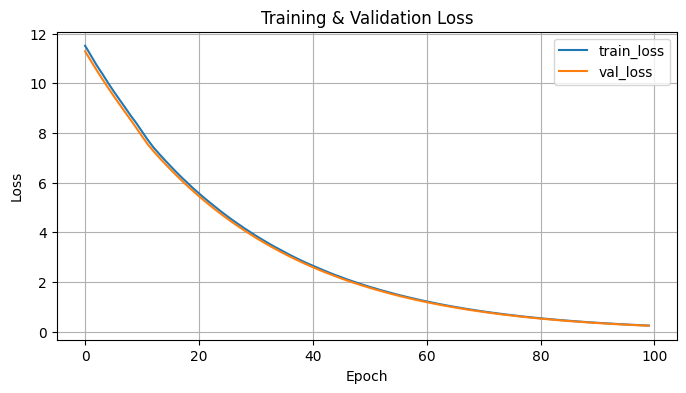

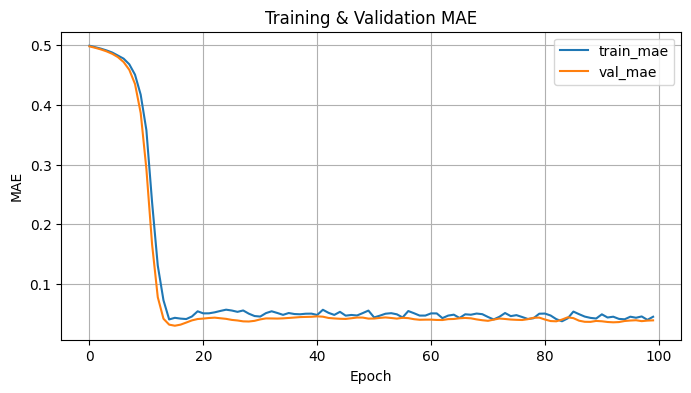

In [15]:
import matplotlib.pyplot as plt

# 1) Plot Loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'],    label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 2) Plot MAE (atau metric lain yang kamu pakai)
plt.figure(figsize=(8,4))
plt.plot(history.history['mae'],     label='train_mae')
plt.plot(history.history['val_mae'], label='val_mae')
plt.title('Training & Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()